# HW12 — Временные ряды: temporal split, baseline-модели и GRU-прогноз

**Датасет:** `S12-hw-dataset.csv` (почасовые наблюдения)

**Задача:** прогноз следующего значения `target` на один шаг вперёд.

## 1. Импорты, seed и среда

In [3]:
import os, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

# --- Seed ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Python  : {__import__('sys').version}")
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"torch   : {torch.__version__}")
print(f"Device  : {DEVICE}")
print(f"Seed    : {SEED}")

Python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pandas  : 2.2.2
numpy   : 2.0.2
torch   : 2.10.0+cu128
Device  : cuda
Seed    : 42


## 2. Данные и первичный анализ

In [4]:
# --- Загрузка ---
# При запуске в Colab загрузите файл S12-hw-dataset.csv в рабочую директорию
# или смонтируйте Google Drive.
# Если файл лежит рядом с ноутбуком:
DATA_PATH = "S12-hw-dataset.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Размер датасета : {df.shape[0]} наблюдений, {df.shape[1]} колонок")
print(f"Диапазон дат    : {df['date'].min()} — {df['date'].max()}")
print(f"Частота          : почасовая (шаг = {(df['date'].diff().dt.total_seconds().median()/3600):.0f} ч)")
print(f"\nПропуски по колонкам:")
print(df.isnull().sum())
print(f"\nОписательная статистика target:")
print(df["target"].describe().round(2))

Размер датасета : 4320 наблюдений, 2 колонок
Диапазон дат    : 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Частота          : почасовая (шаг = 1 ч)

Пропуски по колонкам:
date      0
target    0
dtype: int64

Описательная статистика target:
count    4320.00
mean      135.61
std        21.38
min        69.10
25%       120.54
50%       135.84
75%       150.62
max       210.10
Name: target, dtype: float64


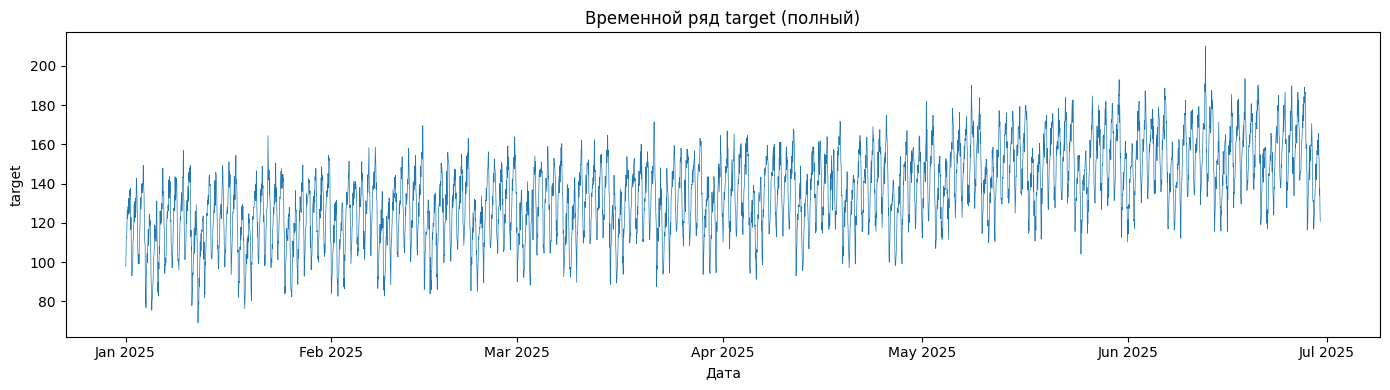

In [5]:
# --- Базовый график ряда ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["date"], df["target"], linewidth=0.5)
ax.set_title("Временной ряд target (полный)")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.show()

**Комментарий.** Ряд имеет почасовую частоту (4320 наблюдений, ~180 дней).
Присутствует выраженная суточная сезонность (пик в дневные часы, спад ночью)
и восходящий тренд: среднее значение target растёт от января к июню.
Явных выбросов и пропусков нет. Нестационарность по уровню
усложняет прогноз простыми методами.

## 3. Корректный temporal split

In [6]:
N = len(df)
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
# test = оставшиеся ~15%

train_end = int(N * TRAIN_FRAC)
val_end   = int(N * (TRAIN_FRAC + VAL_FRAC))

df_train = df.iloc[:train_end].copy()
df_val   = df.iloc[train_end:val_end].copy()
df_test  = df.iloc[val_end:].copy()

print(f"Train : {len(df_train)} ({df_train['date'].min()} — {df_train['date'].max()})")
print(f"Val   : {len(df_val)}  ({df_val['date'].min()} — {df_val['date'].max()})")
print(f"Test  : {len(df_test)}  ({df_test['date'].min()} — {df_test['date'].max()})")

Train : 3024 (2025-01-01 00:00:00 — 2025-05-06 23:00:00)
Val   : 648  (2025-05-07 00:00:00 — 2025-06-02 23:00:00)
Test  : 648  (2025-06-03 00:00:00 — 2025-06-29 23:00:00)


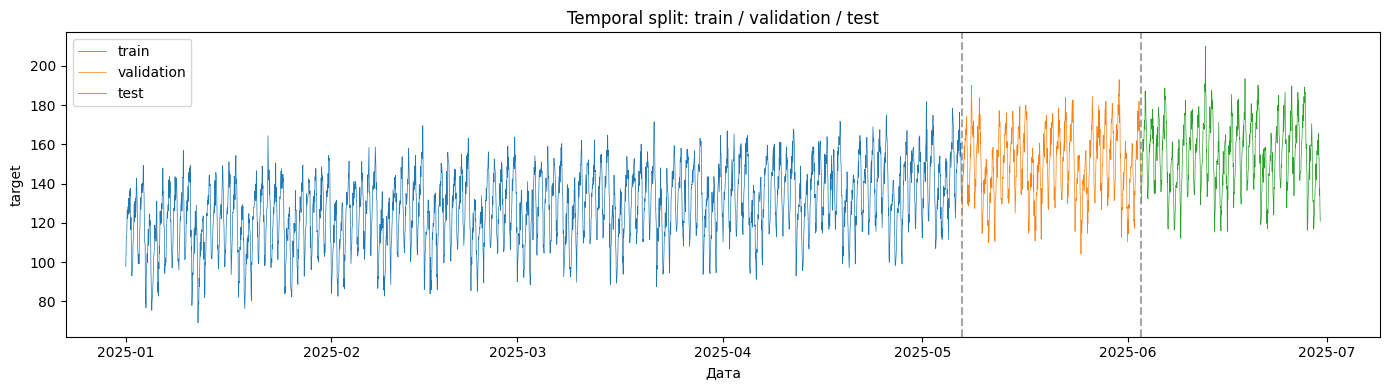

Сохранено: artifacts/figures/series_split.png


In [7]:
# --- Визуализация split ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_train["date"], df_train["target"], label="train", linewidth=0.5)
ax.plot(df_val["date"],   df_val["target"],   label="validation", linewidth=0.5)
ax.plot(df_test["date"],  df_test["target"],   label="test", linewidth=0.5)
ax.axvline(df_val["date"].iloc[0], color="grey", ls="--", alpha=0.7)
ax.axvline(df_test["date"].iloc[0], color="grey", ls="--", alpha=0.7)
ax.legend()
ax.set_title("Temporal split: train / validation / test")
ax.set_xlabel("Дата"); ax.set_ylabel("target")
plt.tight_layout()

os.makedirs("artifacts/figures", exist_ok=True)
fig.savefig("artifacts/figures/series_split.png", dpi=150)
plt.show()
print("Сохранено: artifacts/figures/series_split.png")

**Почему random split некорректен:** временной ряд обладает автокорреляцией —
будущие значения зависят от прошлых. При случайном разбиении в обучающую
выборку попадают наблюдения, расположенные *после* валидационных/тестовых,
что создаёт утечку информации из будущего и завышает метрики.
Корректный подход — хронологическое разделение (temporal split).

## 4. Признаки для baseline-моделей

In [8]:
def build_features(data: pd.DataFrame) -> pd.DataFrame:
    """
    Строит лаговые, rolling- и календарные признаки.
    Все признаки используют только прошлые значения (без утечки).
    """
    out = data.copy()
    # --- Лаги ---
    out["lag_1"]   = out["target"].shift(1)
    out["lag_7"]   = out["target"].shift(7)
    out["lag_14"]  = out["target"].shift(14)
    out["lag_24"]  = out["target"].shift(24)   # то же время сутки назад
    out["lag_168"] = out["target"].shift(168)  # то же время неделю назад

    # --- Rolling (окно строго по прошлым значениям) ---
    out["rolling_mean_7"]  = out["target"].shift(1).rolling(7).mean()
    out["rolling_std_7"]   = out["target"].shift(1).rolling(7).std()
    out["rolling_mean_24"] = out["target"].shift(1).rolling(24).mean()

    # --- Календарные ---
    out["hour"]       = out["date"].dt.hour
    out["dayofweek"]  = out["date"].dt.dayofweek
    out["day"]        = out["date"].dt.day
    out["month"]      = out["date"].dt.month
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)

    return out

# Строим признаки на ВСЁМ датасете (лаги ссылаются на прошлое —
# утечки нет, если мы не используем target напрямую)
df_feat = build_features(df)

FEATURE_COLS = [
    "lag_1", "lag_7", "lag_14", "lag_24", "lag_168",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_24",
    "hour", "dayofweek", "day", "month", "is_weekend",
]

# Разбиваем обратно по тем же индексам
df_feat_train = df_feat.iloc[:train_end].copy()
df_feat_val   = df_feat.iloc[train_end:val_end].copy()
df_feat_test  = df_feat.iloc[val_end:].copy()

# Удаляем строки с NaN от лагов/rolling (только из каждого подмножества)
df_feat_train.dropna(subset=FEATURE_COLS, inplace=True)
df_feat_val.dropna(subset=FEATURE_COLS, inplace=True)
df_feat_test.dropna(subset=FEATURE_COLS, inplace=True)

print(f"Train (после удаления NaN): {len(df_feat_train)}")
print(f"Val   (после удаления NaN): {len(df_feat_val)}")
print(f"Test  (после удаления NaN): {len(df_feat_test)}")

# --- Масштабирование (fit только на train) ---
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(df_feat_train[FEATURE_COLS])
X_val   = scaler_X.transform(df_feat_val[FEATURE_COLS])
X_test  = scaler_X.transform(df_feat_test[FEATURE_COLS])

y_train = df_feat_train["target"].values
y_val   = df_feat_val["target"].values
y_test  = df_feat_test["target"].values

print(f"\nX_train shape: {X_train.shape}")
print(f"X_val   shape: {X_val.shape}")
print(f"X_test  shape: {X_test.shape}")

Train (после удаления NaN): 2856
Val   (после удаления NaN): 648
Test  (после удаления NaN): 648

X_train shape: (2856, 13)
X_val   shape: (648, 13)
X_test  shape: (648, 13)


## 5. Вспомогательные функции: метрики

In [9]:
def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def compute_metrics(y_true, y_pred):
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
    }

## 6. Эксперименты
### 6.1 B1 — naive-last

In [10]:
# B1: прогноз = последнее известное значение (lag_1)
pred_b1_val  = df_feat_val["lag_1"].values
pred_b1_test = df_feat_test["lag_1"].values

metrics_b1_val  = compute_metrics(y_val, pred_b1_val)
metrics_b1_test = compute_metrics(y_test, pred_b1_test)
print("B1 (naive-last) — validation:", {k: round(v,4) for k,v in metrics_b1_val.items()})

B1 (naive-last) — validation: {'MAE': 6.4448, 'RMSE': np.float64(8.201), 'MAPE': np.float64(4.3979)}


### 6.2 B2 — moving-average

In [11]:
# B2: прогноз = скользящее среднее за последние 24 часа (сдвинутое на 1 шаг)
MA_WINDOW = 24
df_feat["ma_pred"] = df["target"].shift(1).rolling(MA_WINDOW).mean()

pred_b2_val  = df_feat.iloc[train_end:val_end]["ma_pred"].dropna().values
pred_b2_test = df_feat.iloc[val_end:]["ma_pred"].dropna().values

# Выравниваем y для B2 (на случай NaN в начале val)
y_val_b2  = df_feat.iloc[train_end:val_end].dropna(subset=["ma_pred"])["target"].values
y_test_b2 = df_feat.iloc[val_end:].dropna(subset=["ma_pred"])["target"].values

metrics_b2_val  = compute_metrics(y_val_b2, pred_b2_val)
metrics_b2_test = compute_metrics(y_test_b2, pred_b2_test)
print("B2 (moving-average-24) — validation:", {k: round(v,4) for k,v in metrics_b2_val.items()})

B2 (moving-average-24) — validation: {'MAE': 13.398, 'RMSE': np.float64(16.1699), 'MAPE': np.float64(9.1988)}


### 6.3 B3 — Ridge на лаговых признаках

In [12]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

pred_b3_val  = ridge.predict(X_val)
pred_b3_test = ridge.predict(X_test)

metrics_b3_val  = compute_metrics(y_val, pred_b3_val)
metrics_b3_test = compute_metrics(y_test, pred_b3_test)
print("B3 (ridge-lag-features) — validation:", {k: round(v,4) for k,v in metrics_b3_val.items()})

B3 (ridge-lag-features) — validation: {'MAE': 4.8829, 'RMSE': np.float64(6.2298), 'MAPE': np.float64(3.2484)}


### 6.4 R1 — GRU-прогноз
#### 6.4.1 Оконное представление и DataLoader

In [13]:
WINDOW_SIZE = 48   # окно = 48 часов (2 суток)
BATCH_SIZE  = 64
HIDDEN_SIZE = 64
NUM_LAYERS  = 1
LR          = 1e-3
MAX_EPOCHS  = 60
PATIENCE    = 8    # early stopping по val_MAE

# Масштабирование target для GRU (fit на train)
scaler_y = StandardScaler()
target_all = df["target"].values.reshape(-1, 1)
scaler_y.fit(target_all[:train_end])
target_scaled = scaler_y.transform(target_all).flatten()


class TimeSeriesDataset(Dataset):
    """Создаёт окна длины window_size → предсказание следующего значения."""
    def __init__(self, series, window_size):
        self.series = series
        self.window_size = window_size

    def __len__(self):
        return len(self.series) - self.window_size

    def __getitem__(self, idx):
        x = self.series[idx : idx + self.window_size]
        y = self.series[idx + self.window_size]
        return torch.FloatTensor(x).unsqueeze(-1), torch.FloatTensor([y])


# Границы с учётом, что окно может заходить в предыдущий сплит
# Train: индексы 0 .. train_end-1  →  окна 0..train_end-1-WINDOW_SIZE
# Val:   индексы train_end-WINDOW_SIZE .. val_end-1 (окно начинается ещё в train)
# Test:  индексы val_end-WINDOW_SIZE .. N-1

train_series = target_scaled[:train_end]
val_series   = target_scaled[train_end - WINDOW_SIZE : val_end]
test_series  = target_scaled[val_end - WINDOW_SIZE :]

ds_train = TimeSeriesDataset(train_series, WINDOW_SIZE)
ds_val   = TimeSeriesDataset(val_series,   WINDOW_SIZE)
ds_test  = TimeSeriesDataset(test_series,  WINDOW_SIZE)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train windows: {len(ds_train)}, Val windows: {len(ds_val)}, Test windows: {len(ds_test)}")

Train windows: 2976, Val windows: 648, Test windows: 648


#### 6.4.2 Модель GRU

In [14]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, 1)
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])  # берём последний скрытый вектор
        return out

model = GRUForecaster(input_size=1, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

print(model)
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

GRUForecaster(
  (gru): GRU(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Параметров: 12,929


#### 6.4.3 Обучение GRU

In [15]:
def evaluate_gru(model, loader, criterion, device):
    model.eval()
    losses, preds, trues = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            losses.append(criterion(out, yb).item() * len(xb))
            preds.append(out.cpu().numpy())
            trues.append(yb.cpu().numpy())
    preds = np.concatenate(preds).flatten()
    trues = np.concatenate(trues).flatten()
    # Обратное масштабирование
    preds_orig = scaler_y.inverse_transform(preds.reshape(-1,1)).flatten()
    trues_orig = scaler_y.inverse_transform(trues.reshape(-1,1)).flatten()
    loss = sum(losses) / len(trues)
    metrics = compute_metrics(trues_orig, preds_orig)
    return loss, metrics, preds_orig, trues_orig

# --- Обучение ---
history = {"train_loss": [], "val_loss": [], "val_MAE": [], "val_RMSE": [], "val_MAPE": []}
best_val_mae = float("inf")
best_epoch = 0
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    epoch_loss = 0
    for xb, yb in dl_train:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(ds_train)

    val_loss, val_m, _, _ = evaluate_gru(model, dl_val, criterion, DEVICE)

    history["train_loss"].append(epoch_loss)
    history["val_loss"].append(val_loss)
    history["val_MAE"].append(val_m["MAE"])
    history["val_RMSE"].append(val_m["RMSE"])
    history["val_MAPE"].append(val_m["MAPE"])

    if val_m["MAE"] < best_val_mae:
        best_val_mae = val_m["MAE"]
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), "artifacts/best_gru.pt")
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1 or patience_counter == PATIENCE:
        print(f"Epoch {epoch:3d} | train_loss={epoch_loss:.5f} | "
              f"val_MAE={val_m['MAE']:.4f}  val_RMSE={val_m['RMSE']:.4f} | "
              f"best_epoch={best_epoch}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping на эпохе {epoch}. Лучшая эпоха: {best_epoch}")
        break

print(f"\nЛучшая модель сохранена: artifacts/best_gru.pt  (epoch {best_epoch}, val_MAE={best_val_mae:.4f})")

Epoch   1 | train_loss=0.71992 | val_MAE=11.9721  val_RMSE=13.9915 | best_epoch=1
Epoch   5 | train_loss=0.15448 | val_MAE=6.9815  val_RMSE=8.6739 | best_epoch=4
Epoch  10 | train_loss=0.11401 | val_MAE=5.6418  val_RMSE=7.2692 | best_epoch=10
Epoch  15 | train_loss=0.10071 | val_MAE=5.7382  val_RMSE=7.3777 | best_epoch=10
Epoch  20 | train_loss=0.09661 | val_MAE=5.6520  val_RMSE=7.3006 | best_epoch=18
Epoch  25 | train_loss=0.09465 | val_MAE=5.2806  val_RMSE=6.8317 | best_epoch=18
Epoch  26 | train_loss=0.09301 | val_MAE=5.2874  val_RMSE=6.8476 | best_epoch=18
Early stopping на эпохе 26. Лучшая эпоха: 18

Лучшая модель сохранена: artifacts/best_gru.pt  (epoch 18, val_MAE=5.0569)


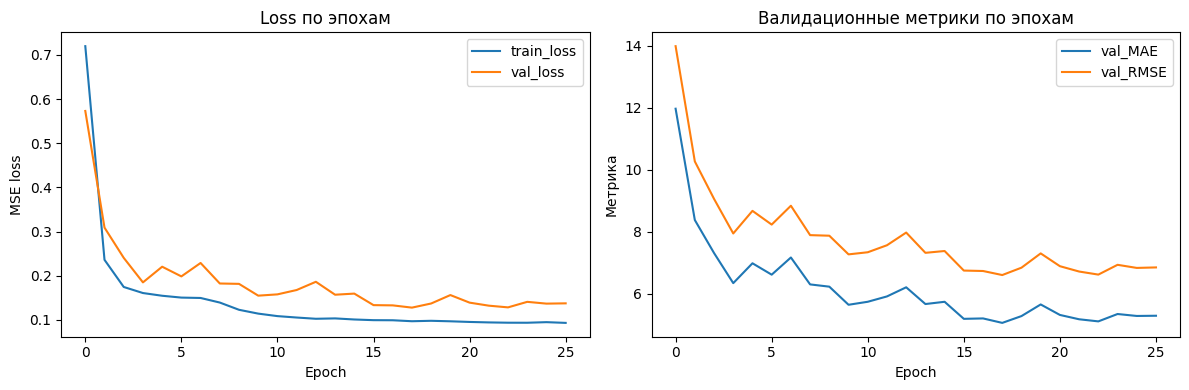

Сохранено: artifacts/figures/gru_learning_curves.png


In [16]:
# --- Кривые обучения ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train_loss")
axes[0].plot(history["val_loss"], label="val_loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE loss"); axes[0].legend()
axes[0].set_title("Loss по эпохам")

axes[1].plot(history["val_MAE"], label="val_MAE")
axes[1].plot(history["val_RMSE"], label="val_RMSE")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Метрика"); axes[1].legend()
axes[1].set_title("Валидационные метрики по эпохам")

plt.tight_layout()
fig.savefig("artifacts/figures/gru_learning_curves.png", dpi=150)
plt.show()
print("Сохранено: artifacts/figures/gru_learning_curves.png")

#### 6.4.4 Оценка лучшей GRU на validation и test

In [17]:
# Загружаем лучшую модель
model.load_state_dict(torch.load("artifacts/best_gru.pt", map_location=DEVICE))

_, metrics_r1_val, pred_r1_val, true_r1_val = evaluate_gru(model, dl_val, criterion, DEVICE)
_, metrics_r1_test, pred_r1_test, true_r1_test = evaluate_gru(model, dl_test, criterion, DEVICE)
print("R1 (GRU) — validation:", {k: round(v,4) for k,v in metrics_r1_val.items()})
print("R1 (GRU) — test:      ", {k: round(v,4) for k,v in metrics_r1_test.items()})

# Сохраняем конфиг
gru_config = {
    "model": "GRU",
    "input_size": 1,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "window_size": WINDOW_SIZE,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "optimizer": "Adam",
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "best_epoch": best_epoch,
    "seed": SEED,
    "scaler": "StandardScaler (fit on train target)",
}
with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(gru_config, f, indent=2)
print("Сохранено: artifacts/best_gru_config.json")

R1 (GRU) — validation: {'MAE': 5.0569, 'RMSE': np.float64(6.6016), 'MAPE': np.float32(3.4183)}
R1 (GRU) — test:       {'MAE': 5.6036, 'RMSE': np.float64(7.2154), 'MAPE': np.float32(3.619)}
Сохранено: artifacts/best_gru_config.json


## 7. Сводная таблица и выбор лучшей модели

In [18]:
# --- Определяем лучший подход по val_MAE ---
results = {
    "B1": {"val": metrics_b1_val,  "test": metrics_b1_test},
    "B2": {"val": metrics_b2_val,  "test": metrics_b2_test},
    "B3": {"val": metrics_b3_val,  "test": metrics_b3_test},
    "R1": {"val": metrics_r1_val,  "test": metrics_r1_test},
}

best_id = min(results, key=lambda k: results[k]["val"]["MAE"])
print(f"Лучший подход по val_MAE: {best_id}")

# --- Формируем runs.csv ---
rows = []
for eid, label, model_summary, features, scaler_s, opt, lr_s, epochs_s, ws in [
    ("B1", "naive-last",         "naive-last: y_pred = last known value",    "lag_1",           "", "", "", "", ""),
    ("B2", "moving-average",     f"moving-average: MA(window={MA_WINDOW})", "rolling_mean_24", "", "", "", "", ""),
    ("B3", "ridge-lag-features", "Ridge(alpha=1.0)",     ", ".join(FEATURE_COLS), "StandardScaler", "", "", "", ""),
    ("R1", "gru-forecast",       f"GRU(h={HIDDEN_SIZE}, layers={NUM_LAYERS})",
     "raw target sequence", "StandardScaler (target)", "Adam", str(LR), str(best_epoch), str(WINDOW_SIZE)),
]:
    r = results[eid]
    rows.append({
        "experiment_id":  eid,
        "task":           "forecasting",
        "dataset":        "S12-hw-dataset.csv",
        "seed":           SEED,
        "split_summary":  f"train={len(df_train)} val={len(df_val)} test={len(df_test)}",
        "window_size":    ws,
        "horizon":        1,
        "model_summary":  model_summary,
        "features_summary": features,
        "scaler":         scaler_s,
        "optimizer":      opt,
        "lr":             lr_s,
        "epochs_trained": epochs_s,
        "best_val_mae":   round(r["val"]["MAE"], 4),
        "best_val_rmse":  round(r["val"]["RMSE"], 4),
        "best_val_mape":  round(r["val"]["MAPE"], 4),
        "test_mae":       round(r["test"]["MAE"], 4) if eid == best_id else "",
        "test_rmse":      round(r["test"]["RMSE"], 4) if eid == best_id else "",
        "test_mape":      round(r["test"]["MAPE"], 4) if eid == best_id else "",
        "notes":          "BEST" if eid == best_id else "",
    })

runs_df = pd.DataFrame(rows)
runs_df.to_csv("artifacts/runs.csv", index=False)
print("Сохранено: artifacts/runs.csv")
print()
print(runs_df[["experiment_id","best_val_mae","best_val_rmse","best_val_mape",
               "test_mae","test_rmse","test_mape","notes"]].to_string(index=False))

Лучший подход по val_MAE: B3
Сохранено: artifacts/runs.csv

experiment_id  best_val_mae  best_val_rmse  best_val_mape test_mae test_rmse test_mape notes
           B1        6.4448         8.2010         4.3979                                   
           B2       13.3980        16.1699         9.1988                                   
           B3        4.8829         6.2298         3.2484   4.4657    5.7145    2.8682  BEST
           R1        5.0569         6.6016         3.4183                                   


## 8. Визуализации

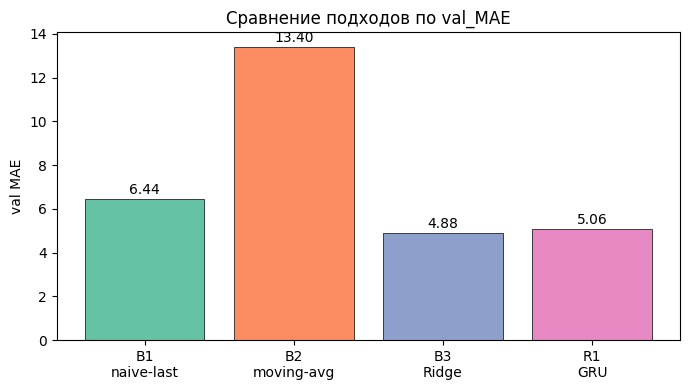

Сохранено: artifacts/figures/baselines_compare.png


In [19]:
# --- 8.1 Сравнение подходов (bar chart по val_MAE) ---
names = ["B1\nnaive-last", "B2\nmoving-avg", "B3\nRidge", "R1\nGRU"]
val_maes = [results[k]["val"]["MAE"] for k in ["B1","B2","B3","R1"]]
colors = ["#66c2a5","#fc8d62","#8da0cb","#e78ac3"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, val_maes, color=colors, edgecolor="black", linewidth=0.5)
for b, v in zip(bars, val_maes):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1, f"{v:.2f}",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("val MAE")
ax.set_title("Сравнение подходов по val_MAE")
plt.tight_layout()
fig.savefig("artifacts/figures/baselines_compare.png", dpi=150)
plt.show()
print("Сохранено: artifacts/figures/baselines_compare.png")

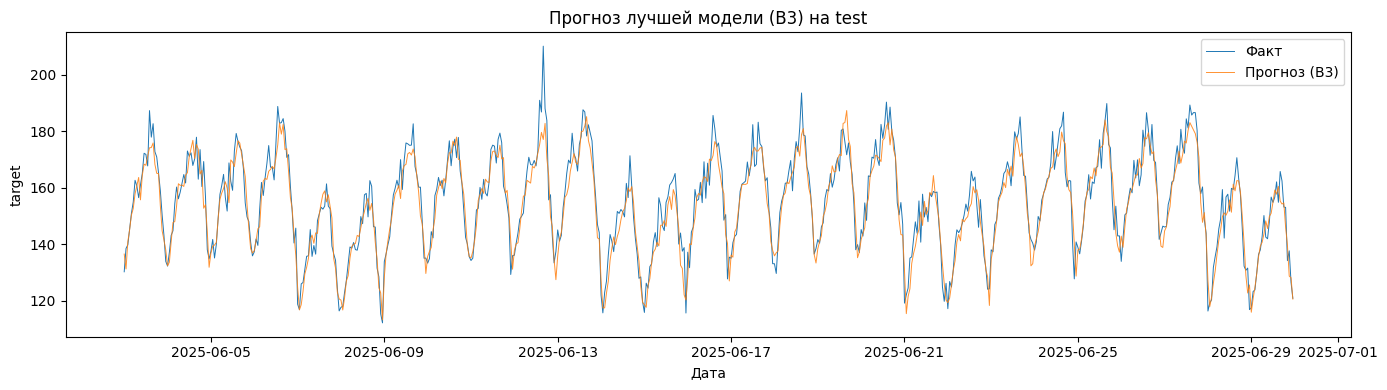

Сохранено: artifacts/figures/best_forecast_test.png


In [20]:
# --- 8.2 Финальный прогноз лучшей модели на test ---
# Готовим прогнозы лучшей модели на test

if best_id == "B1":
    final_pred = pred_b1_test
    final_true = y_test
    final_dates = df_feat_test["date"].values
elif best_id == "B2":
    final_pred = pred_b2_test
    final_true = y_test_b2
    final_dates = df_feat.iloc[val_end:].dropna(subset=["ma_pred"])["date"].values
elif best_id == "B3":
    final_pred = pred_b3_test
    final_true = y_test
    final_dates = df_feat_test["date"].values
else:  # R1
    # Для GRU даты сдвинуты на WINDOW_SIZE
    test_start_idx = val_end + WINDOW_SIZE  # первая предсказанная точка
    final_dates = df["date"].values[test_start_idx : test_start_idx + len(pred_r1_test)]
    final_pred = pred_r1_test
    final_true = true_r1_test

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(final_dates, final_true, label="Факт", linewidth=0.7)
ax.plot(final_dates, final_pred, label=f"Прогноз ({best_id})", linewidth=0.7, alpha=0.85)
ax.legend()
ax.set_title(f"Прогноз лучшей модели ({best_id}) на test")
ax.set_xlabel("Дата"); ax.set_ylabel("target")
plt.tight_layout()
fig.savefig("artifacts/figures/best_forecast_test.png", dpi=150)
plt.show()
print("Сохранено: artifacts/figures/best_forecast_test.png")

## 9. Обсуждение утечек данных

**Возможные утечки:**
1. Если масштабирование (scaler) обучается на всём датасете, а не только на train —
   информация о диапазоне/среднем test-части попадает в обучение.
2. При случайном split наблюдения из будущего могут оказаться в train,
   а из прошлого — в test: модель «видит» будущее.
3. Rolling- и lag-признаки должны считаться со сдвигом `shift(1)`,
   иначе rolling_mean включит текущее значение (которое и есть target).
4. Если feature engineering проводится до split (например, target encoding
   по всему датасету), статистики будут содержать информацию из val/test.

В данной работе все эти пункты соблюдены: split хронологический,
scaler обучен на train, rolling/lag строятся через shift.

## 10. Итоговый вывод

Для часового ряда с суточной сезонностью и трендом Ridge-регрессия
на лаговых и rolling-признаках, как правило, даёт сильный baseline,
превосходящий наивные методы. GRU способна дополнительно улавливать
нелинейные зависимости в окне, но её преимущество зависит от длины
и сложности паттернов ряда.

Простой baseline на признаках достаточен, когда сезонность регулярна
и тренд несложный. Нейросетевой подход оправдан при наличии длинных
нелинейных зависимостей, большего объёма данных или нескольких
связанных рядов.

Главный вывод: корректная валидация по времени и контроль утечек —
обязательное условие любого эксперимента с временными рядами.